# PIPE-SOGI v2p — Camada de Risco (VaR/ES) e Índice de Risco Financeiro (FRI)

**Braço probabilístico** — protocolo de 95% de confiança.

Este notebook roda toda a análise de risco dos quatro mercados a partir dos
resultados de previsão já gerados (`result/v2p_result_steel_<cc>.xlsx`). Ele é
**independente do treino**: reproduz a camada de risco do zero, sem re-rodar os
modelos.

**Protocolo (v2p):**
- Perda de compra assinada $L_t=\ln(y_t/\hat{y}_t)$ (positivo = preço acima da previsão = perda do comprador).
- VaR/ES a **95%** (contexto de tesouraria corporativa; potência estatística: ~50 exceções esperadas em n≈1000).
- **8 métodos de VaR por engine:** 7 residuais rolantes (Historical, WeightedHS, CornishFisher, FHS-EWMA, EVT, GJR-GARCH-t, EGARCH-skewt) + os quantis nativos da rede em 3 formas: `NativeQR` (cru), `ConformalQR` (CQR normalizada por volatilidade) e `ACI-QR` (Adaptive Conformal Inference, $\gamma=0{,}05$).
- **Backtests:** Kupiec95, Christoffersen e DQ — reportados na versão padrão **e desobreposta** (`_str`, a cada $h$ passos), pois a $h=5$ as previsões *one-shot* se sobrepõem e contaminam os testes de independência (mesma lógica do teste de Diebold-Mariano com passo $h$).
- **FRI v2p** $= \text{QS95}_{norm} \times R_{norm} \times k$ — índice de risco puro: score de quantil (pinball, próprio) × severidade de cauda (ES/VaR) × penalidade de validade. **Sem SMAPE.**

**Pré-requisitos:** `var_v2p.py` na pasta · `pip install arch` · os quatro `result/v2p_result_steel_{chi,usa,ger,tur}.xlsx`.

## 1. Configuração

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import var_v2p as vv

# País -> horizonte primário pré-especificado (célula primária da tese)
MARKETS = {"CHI": 5, "USA": 5, "GER": 5, "TUR": 5}

# Seleção dinâmica de engines: benchmarks fixos + Top-3 DL + Top-3 ensemble,
# lidos da aba rank_prob (pinball/Winkler) de cada país.
DL  = {"RNN", "Transformer", "N-HiTS", "DLinear", "TCN", "TSMixer"}
ENS = {"EnsMean", "EnsDynSMAPE", "EnsPinballDyn",
       "EnsRegTop3", "EnsResidChamp", "EnsShrink"}
FIXED = ["NaiveH", "LinearRegression", "ARIMA"]
MPFX = {"RNN": "rnn", "Transformer": "trans", "N-HiTS": "nhits", "DLinear": "dlinear",
        "TCN": "tcn", "TSMixer": "tsmixer", "ARIMA": "arima", "LinearRegression": "lr",
        "NaiveH": "naive", "EnsMean": "EnsMean", "EnsDynSMAPE": "EnsDynSMAPE",
        "EnsPinballDyn": "EnsPinballDyn"}

def engines_for(cc, h):
    """Benchmarks fixos + Top-3 DL + Top-3 ensemble da aba rank_prob do país."""
    rank = pd.read_excel(f"result/v2p_result_steel_{cc.lower()}.xlsx", "rank_prob")
    blk = rank[rank.h == h].sort_values("TOTAL_scr", ascending=False)
    top_dl  = [m for m in blk.Model if m in DL][:3]
    top_ens = [m for m in blk.Model if m in ENS][:3]
    print(f"  [{cc}|h={h}] engines: DL={top_dl} | ENS={top_ens}")
    return {MPFX[m]: m for m in FIXED + top_dl + top_ens}

plt.rcParams.update({"figure.dpi": 120})

## 2. Backtest + FRI dos quatro países

Para cada mercado: seleciona os engines pelo `rank_prob`, roda os 8 métodos de VaR por engine, escolhe o melhor método válido por menor QS95 (`select_best_method`) e compõe o FRI. Cada país é salvo em `result/v2p_var_fri_<cc>.xlsx` e tudo é consolidado em `result/v2p_var_fri_ALL.xlsx`.

⚠️ ~15–20 min no total (dominado pelo refit rolante do GARCH).

In [2]:
all_bt, all_fri = [], []

for cc, h in MARKETS.items():
    print(f"===== {cc} | h={h} =====")
    f = f"result/v2p_result_steel_{cc.lower()}.xlsx"
    ENGINES = engines_for(cc, h)
    summ = pd.read_excel(f, sheet_name=f"summary_{cc.lower()}")
    smape_map = {p: float(summ[(summ.Model == m) & (summ.h == h)].SMAPE.iloc[0])
                 for p, m in ENGINES.items()}

    best_rows, bt = [], []
    for pfx in ENGINES:
        df_e, series, dates, L = vv.run_engine(f, cc, h, pfx)
        df_e.insert(0, "cell", f"{cc}_h{h}")
        bt.append(df_e)
        best = vv.select_best_method(df_e)
        best_rows.append(best)
        print(f"  {pfx:10s} -> {best.Method:14s} Kup95={best.Kupiec95:.3f} "
              f"DQstr={best.DQ95_str:.3f} QS95={best.QS95:.5f} R={best.ES_VaR_ratio:.3f}")

    bt_cc  = pd.concat(bt, ignore_index=True)
    fri_cc = vv.fri_table(best_rows, smape_map); fri_cc["cell"] = f"{cc}_h{h}"
    with pd.ExcelWriter(f"result/v2p_var_fri_{cc.lower()}.xlsx", engine="openpyxl") as w:
        bt_cc.to_excel(w, sheet_name="backtests", index=False)
        fri_cc.to_excel(w, sheet_name="fri", index=False)
    all_bt.append(bt_cc); all_fri.append(fri_cc)
    print()

full_bt = pd.concat(all_bt, ignore_index=True)
fri_all = pd.concat(all_fri, ignore_index=True)
with pd.ExcelWriter("result/v2p_var_fri_ALL.xlsx", engine="openpyxl") as w:
    full_bt.to_excel(w, sheet_name="backtests_all", index=False)
    fri_all.to_excel(w, sheet_name="fri", index=False)
print("OK -> result/v2p_var_fri_ALL.xlsx")

===== CHI | h=5 =====
  [CHI|h=5] engines: DL=['TCN', 'TSMixer', 'N-HiTS'] | ENS=['EnsPinballDyn', 'EnsDynSMAPE', 'EnsMean']
  naive      -> WeightedHS     Kup95=0.960 DQstr=0.409 QS95=0.00119 R=1.637
  lr         -> FHS-EWMA       Kup95=0.540 DQstr=0.782 QS95=0.00099 R=1.425
  arima      -> FHS-EWMA       Kup95=0.060 DQstr=0.705 QS95=0.00096 R=1.362
  tcn        -> ACI-QR         Kup95=0.907 DQstr=0.841 QS95=0.00088 R=2.056
  tsmixer    -> ACI-QR         Kup95=0.907 DQstr=0.835 QS95=0.00085 R=1.693
  nhits      -> ACI-QR         Kup95=0.907 DQstr=0.385 QS95=0.00093 R=1.758
  EnsPinballDyn -> FHS-EWMA       Kup95=0.210 DQstr=0.811 QS95=0.00097 R=1.418
  EnsDynSMAPE -> FHS-EWMA       Kup95=0.273 DQstr=0.773 QS95=0.00098 R=1.455
  EnsMean    -> FHS-EWMA       Kup95=0.349 DQstr=0.792 QS95=0.00099 R=1.479

===== USA | h=5 =====
  [USA|h=5] engines: DL=['TCN', 'DLinear', 'N-HiTS'] | ENS=['EnsDynSMAPE', 'EnsPinballDyn', 'EnsMean']
  naive      -> GJR-GARCH-t    Kup95=0.462 DQstr=0.363 QS95=0

## 3. FRI final por mercado (menor = melhor)

In [3]:
for cell in fri_all.cell.unique():
    b = fri_all[fri_all.cell == cell].sort_values("FZ0")   # menor FZ0 = melhor
    print(f"\n===== {cell} =====")
    print(b[["Engine", "Method", "FZ0", "FRI_gain", "QS95", "ES_VaR_ratio", "SMAPE"]]
          .round(4).to_string(index=False))


===== CHI_h5 =====
       Engine     Method     FZ0  FRI_gain   QS95  ES_VaR_ratio  SMAPE
      EnsMean   FHS-EWMA -4.1649    0.3344 0.0010        1.4794 0.7412
  EnsDynSMAPE   FHS-EWMA -4.1468    0.3163 0.0010        1.4548 0.7404
EnsPinballDyn   FHS-EWMA -4.1283    0.2977 0.0010        1.4183 0.7443
           lr   FHS-EWMA -4.1268    0.2962 0.0010        1.4255 0.7423
        arima   FHS-EWMA -4.1247    0.2942 0.0010        1.3624 0.7308
          tcn     ACI-QR -4.1231    0.2926 0.0009        2.0562 0.7286
        nhits     ACI-QR -4.0938    0.2632 0.0009        1.7577 0.7587
      tsmixer     ACI-QR -4.0813    0.2507 0.0008        1.6928 0.7898
        naive WeightedHS -3.8305    0.0000 0.0012        1.6375 0.7172

===== USA_h5 =====
       Engine       Method     FZ0  FRI_gain   QS95  ES_VaR_ratio  SMAPE
        naive  GJR-GARCH-t -4.1626    0.0000 0.0009        1.4089 0.9807
  EnsDynSMAPE EGARCH-skewt -4.1582   -0.0045 0.0008        2.0188 0.9451
        arima  GJR-GARCH-t -4.1

## 4. Validade dos quantis neurais — NativeQR → ConformalQR → ACI-QR

Mostra a "escada" de validação do braço probabilístico: o quantil cru da rede, sua recalibração conformal, e a versão adaptativa (ACI). Colunas-chave: **Kupiec95** (nível), **Indep95_str** e **DQ95_str** (independência/dinâmica desobrepostas, régua correta a $h=5$), **QS95** (nitidez).

In [4]:
neural = full_bt[full_bt.Method.isin(["NativeQR", "ConformalQR", "ACI-QR"])]

# média por método (agregada nos engines DL/ensemble dos quatro países)
agg = (neural.groupby("Method")
       .agg(Kupiec95=("Kupiec95", "mean"), Indep95_str=("Indep95_str", "mean"),
            DQ95_full=("DQ95", "mean"), DQ95_str=("DQ95_str", "mean"),
            QS95=("QS95", "mean"))
       .reindex(["NativeQR", "ConformalQR", "ACI-QR"]).round(4))
print("Média cross-market dos três quantis neurais:")
print(agg.to_string())

# quantas vezes cada método neural foi SELECIONADO como best no FRI
print("\nMétodos neurais selecionados no FRI:")
for mth in ["NativeQR", "ConformalQR", "ACI-QR"]:
    sel = fri_all[fri_all.Method == mth][["cell", "Engine"]].values.tolist()
    print(f"  {mth:12s}: {sel or 'nenhum'}")

Média cross-market dos três quantis neurais:
             Kupiec95  Indep95_str  DQ95_full  DQ95_str    QS95
Method                                                         
NativeQR       0.1975       0.4290        0.0    0.2378  0.0011
ConformalQR    0.2473       0.2780        0.0    0.2473  0.0011
ACI-QR         0.7983       0.4028        0.0    0.5634  0.0009

Métodos neurais selecionados no FRI:
  NativeQR    : nenhum
  ConformalQR : nenhum
  ACI-QR      : [['CHI_h5', 'tcn'], ['CHI_h5', 'nhits'], ['CHI_h5', 'tsmixer'], ['USA_h5', 'tcn'], ['USA_h5', 'EnsPinballDyn']]


## 5. Compressão de buffer — valor econômico do modelo

`meanVaR95` é o colchão médio de compra a 95% (em log ≈ % do preço). Comparado ao NaiveH, mede a economia de capital de um engine que mantém cobertura válida — o número que conecta a camada de previsão a dinheiro.

In [5]:
rows = []
for cc, h in MARKETS.items():
    base = fri_all[(fri_all.cell == f"{cc}_h{h}") & (fri_all.Engine == "naive")]
    base_v = float(base.meanVaR95.iloc[0]) if len(base) else np.nan
    blk = fri_all[fri_all.cell == f"{cc}_h{h}"]
    for _, r in blk.iterrows():
        rows.append(dict(Market=cc, h=h, Engine=r.Engine, Method=r.Method,
                         meanVaR95=round(r.meanVaR95, 4),
                         buffer_vs_naive=f"{(r.meanVaR95/base_v - 1)*100:+.1f}%",
                         valid=(not r.Rejected) and str(r.TL95).startswith("Green")))
comp = pd.DataFrame(rows)
print(comp.to_string(index=False))

Market  h        Engine       Method  meanVaR95 buffer_vs_naive  valid
   CHI  5       EnsMean     FHS-EWMA     0.0114          -17.6%   True
   CHI  5   EnsDynSMAPE     FHS-EWMA     0.0117          -16.0%   True
   CHI  5 EnsPinballDyn     FHS-EWMA     0.0121          -13.0%   True
   CHI  5            lr     FHS-EWMA     0.0125          -10.2%   True
   CHI  5         arima     FHS-EWMA     0.0130           -6.7%  False
   CHI  5           tcn       ACI-QR     0.0122          -11.9%   True
   CHI  5         nhits       ACI-QR     0.0134           -3.9%   True
   CHI  5       tsmixer       ACI-QR     0.0144           +3.5%   True
   CHI  5         naive   WeightedHS     0.0139           +0.0%   True
   USA  5         naive  GJR-GARCH-t     0.0159           +0.0%   True
   USA  5   EnsDynSMAPE EGARCH-skewt     0.0142          -10.8%   True
   USA  5         arima  GJR-GARCH-t     0.0148           -7.5%   True
   USA  5       EnsMean EGARCH-skewt     0.0143          -10.1%   True
   USA

## 6. Trajetória do VaR — melhor engine (por FRI) vs. naive

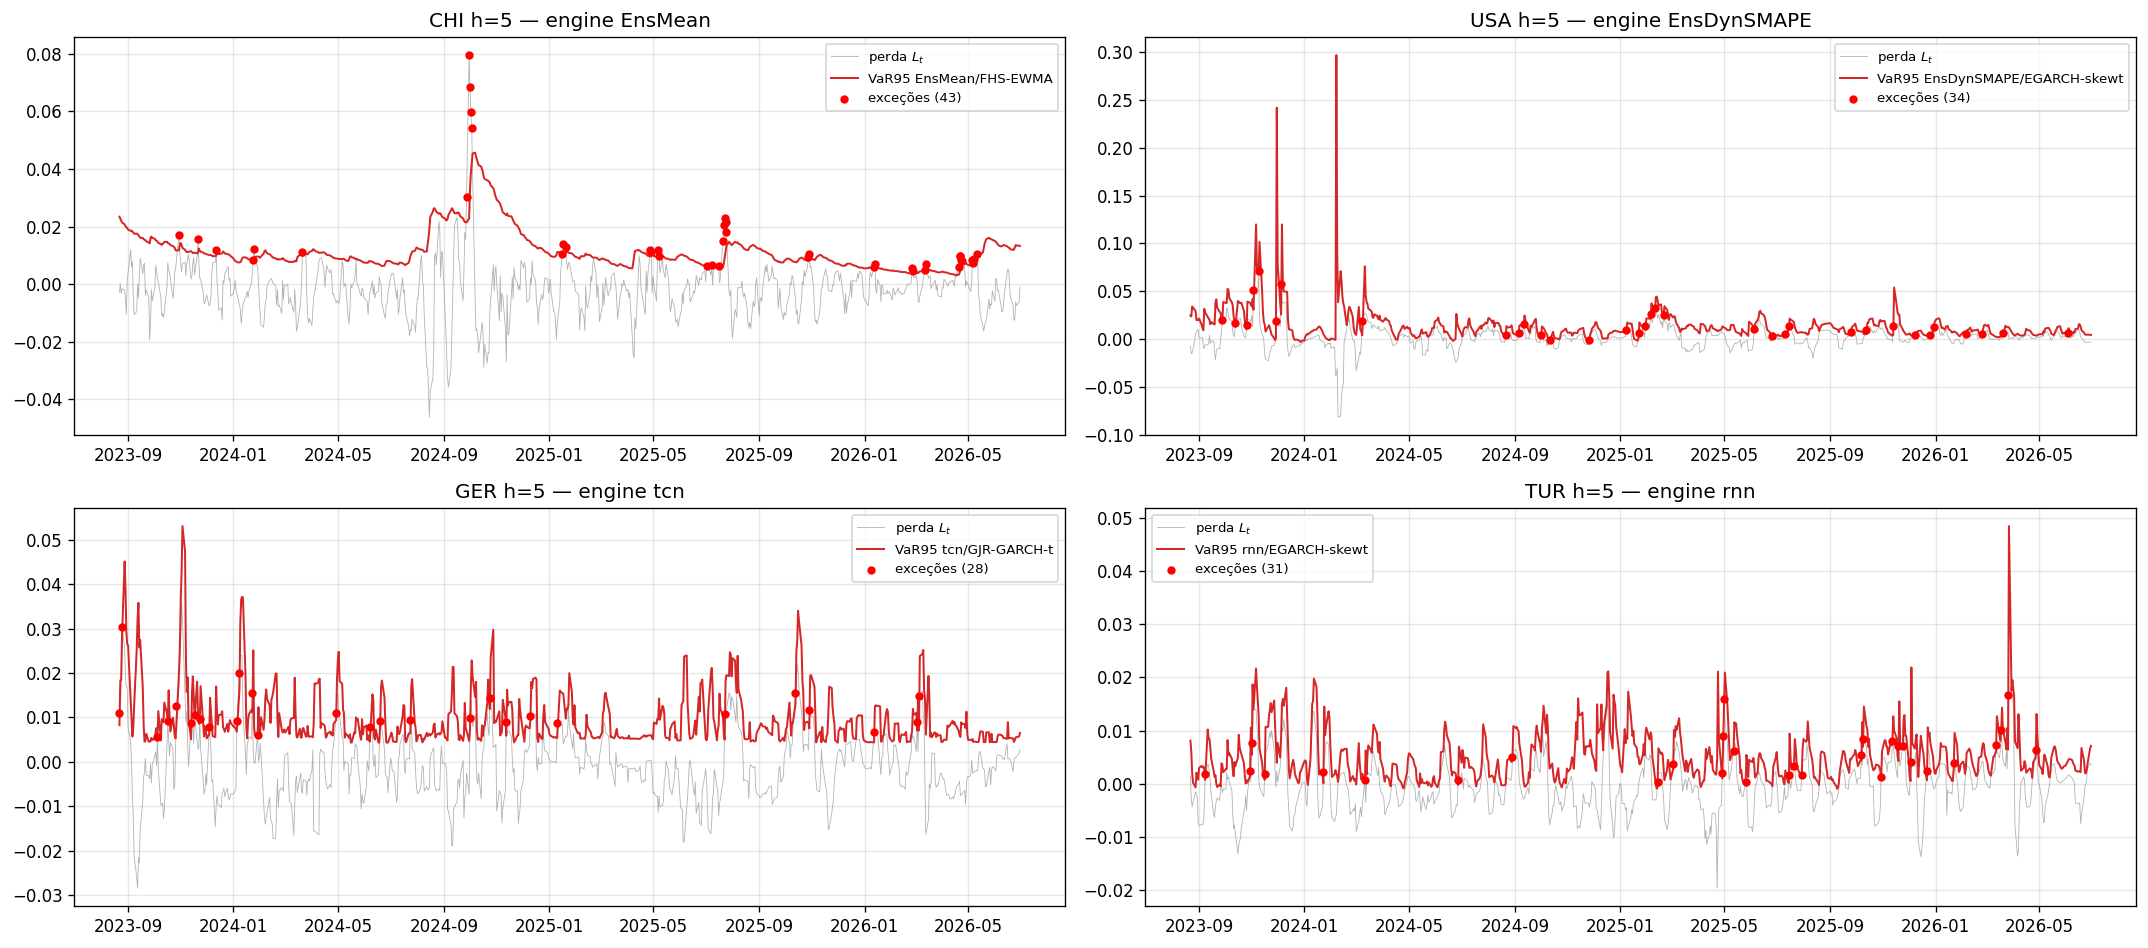

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(18, 8))
for ax, (cc, h) in zip(axes.flat, MARKETS.items()):
    blk = fri_all[(fri_all.cell == f"{cc}_h{h}") & (fri_all.Engine != "naive")]
    best_pfx = blk.sort_values("FZ0").iloc[0].Engine
    best_mth = blk.sort_values("FZ0").iloc[0].Method
    f = f"result/v2p_result_steel_{cc.lower()}.xlsx"
    _, store, dates, L = vv.run_engine(f, cc, h, best_pfx)
    V = store[best_mth][vv.A]["V"]; hits = store[best_mth][vv.A]["hits"]
    ax.plot(dates, L, lw=0.5, color="gray", alpha=0.6, label="perda $L_t$")
    ax.plot(dates, V, lw=1.2, color="#d62728", label=f"VaR95 {best_pfx}/{best_mth}")
    ax.scatter(np.array(dates)[hits], L[hits], s=16, color="red", zorder=5,
               label=f"exceções ({int(hits.sum())})")
    ax.set_title(f"{cc} h={h} — engine {best_pfx}"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("result/v2p_fig_var_trajectories.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Exportação consolidada

In [7]:
with pd.ExcelWriter("result/v2p_var_fri.xlsx", engine="openpyxl") as w:
    full_bt.to_excel(w, sheet_name="backtests_all", index=False)
    fri_all.to_excel(w, sheet_name="fri", index=False)
    comp.to_excel(w, sheet_name="buffer_compression", index=False)
print("OK -> result/v2p_var_fri.xlsx")

OK -> result/v2p_var_fri.xlsx
